# Three-Model × Four-Dataset Evaluation

Evaluates and compares:
- **Model 1**: Original HybridSiam-CD
- **Model 2**: HybridSiam-CD+ (Berlin only)
- **Model 3**: HybridSiam-CD+ (Combined — all 4 datasets)

On all 4 test sets: GBCD-Binary · FOTBCD-Binary · LEVIR-CD+ · WHU-CD

**Just run all cells in order.**

In [ ]:
# ── CELL 1: Mount Drive + Install ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
!pip install albumentations timm -q
print('Ready!')

Mounted at /content/drive
Ready!


In [ ]:
# ── CELL 2: Copy model.py ─────────────────────────────────────────────────────
import shutil, os
shutil.copy('/content/drive/MyDrive/GBCD/model.py', '/content/model.py')
print('model.py copied.')

model.py copied.


In [ ]:
# ── CELL 3: All imports ───────────────────────────────────────────────────────
import os, time, types
from pathlib import Path

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm
from model import HybridChangeDetector

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [ ]:
# ── CELL 4: Paths ─────────────────────────────────────────────────────────────
MODELS = {
    'Original\nHybridSiam-CD': {
        'path': '/content/drive/MyDrive/GBCD/model.pth',
        'type': 'original',
        'color': '#f78166',
    },
    'HybridSiam-CD+\n(Berlin)': {
        'path': '/content/drive/MyDrive/GBCD/best_model_hybridsiam_plus.pth',
        'type': 'plus',
        'color': '#58a6ff',
    },
    'HybridSiam-CD+\n(Combined)': {
        'path': '/content/drive/MyDrive/GBCD/best_model_combined.pth',
        'type': 'plus',
        'color': '#56d364',
    },
}

DATASETS = {
    'GBCD-Binary\n(Berlin)': {
        'path'  : '/content/drive/MyDrive/GBCD/GBCD-Binary/test',
        'before': 'before',
        'after' : 'after',
        'label' : 'label',
    },
    'FOTBCD-Binary\n(French)': {
        'path'  : '/content/drive/MyDrive/GBCD/FOTBCD-Binary/test',
        'before': 'before',
        'after' : 'after',
        'label' : 'label',
    },
    'LEVIR-CD+\n(China)': {
        'path'  : '/content/drive/MyDrive/GBCD/LEVIR-CD+/test',
        'before': 'A',
        'after' : 'B',
        'label' : 'label',
    },
    'WHU-CD\n(China)': {
        'path'  : '/content/drive/MyDrive/GBCD/whu-cd/test',
        'before': 'A',
        'after' : 'B',
        'label' : 'OUT',
    },
}

IMG_SIZE   = 512
MEAN_V     = np.array([0.485, 0.456, 0.406])
STD_V      = np.array([0.229, 0.224, 0.225])
EXTENSIONS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
SAVE_DIR   = '/content/evaluation'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Configuration set.')

Configuration set.


In [ ]:
# ── CELL 5: CBAM + HybridSiamPlus ────────────────────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return x * self.sigmoid(
            self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size,
                                 padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1, keepdim=True)[0]
        return x * self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(spatial_kernel)
    def forward(self, x):
        return self.sa(self.ca(x))

class LearnableTemporalFusion(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Linear(in_dim * 2, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
        )
    def forward(self, feat_before, feat_after):
        return self.conv(torch.cat([feat_before, feat_after], dim=-1))

class HybridSiamPlus(nn.Module):
    def __init__(self):
        super().__init__()
        self.base            = HybridChangeDetector(pretrained=False)
        self.cbam_bottleneck = CBAM(256)
        self.cbam_fuse1      = CBAM(128)
        self.cbam_fuse2      = CBAM(64)
        self.cbam_fuse3      = CBAM(64)
        self.cbam_fuse4      = CBAM(32)
        enc_dim = self.base.encoder.out_dim
        self.temporal_fusion = LearnableTemporalFusion(enc_dim, enc_dim)
        self._patch_encoder()
        self._patch_decoder()

    def _patch_encoder(self):
        fusion = self.temporal_fusion
        def _forward(self_enc, before, after):
            feat_before = self_enc.backbone(before)
            feat_after  = self_enc.backbone(after)
            num_prefix  = getattr(self_enc.backbone, 'num_prefix_tokens', 1)
            feat_before = feat_before[:, num_prefix:]
            feat_after  = feat_after[:, num_prefix:]
            feat_before = self_enc.proj(feat_before)
            feat_after  = self_enc.proj(feat_after)
            return fusion(feat_before, feat_after)
        self.base.encoder.forward = types.MethodType(
            _forward, self.base.encoder)

    def _patch_decoder(self):
        decoder = self.base.decoder
        cbam_bn = self.cbam_bottleneck
        cbam_f1 = self.cbam_fuse1
        cbam_f2 = self.cbam_fuse2
        cbam_f3 = self.cbam_fuse3
        cbam_f4 = self.cbam_fuse4
        def _forward(self_dec, vit_features, resnet_features, output_size):
            B, N, D = vit_features.shape
            h = w = int(N ** 0.5)
            vit = vit_features.permute(0, 2, 1).view(B, D, h, w)
            s0, s1, s2, s3, s4, s5 = resnet_features
            s5_up = F.interpolate(s5, size=(h, w), mode='nearest')
            x = self_dec.bottleneck(torch.cat([vit, s5_up, s4], dim=1))
            x = cbam_bn(x)
            x = self_dec.up1(x)
            x = self_dec.fuse1(torch.cat([x, s3], dim=1))
            x = cbam_f1(x)
            x = self_dec.up2(x)
            x = self_dec.fuse2(torch.cat([x, s2], dim=1))
            x = cbam_f2(x)
            x = self_dec.up3(x)
            x = self_dec.fuse3(torch.cat([x, s1], dim=1))
            x = cbam_f3(x)
            x = self_dec.up4(x)
            x = self_dec.fuse4(torch.cat([x, s0], dim=1))
            x = cbam_f4(x)
            x = self_dec.head(x)
            if x.shape[2:] != output_size:
                x = F.interpolate(x, size=output_size, mode='nearest')
            return x
        decoder.forward = types.MethodType(_forward, decoder)

    def forward(self, before, after):
        return self.base(before, after)

print('Model classes defined.')

Model classes defined.


In [ ]:
# ── CELL 6: Helpers + Metrics ─────────────────────────────────────────────────
def find_label(label_dir, stem):
    for ext in EXTENSIONS:
        p = os.path.join(label_dir, stem + ext)
        if os.path.exists(p): return p
    return None

def prepare_tensor(img_bgr, device):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = (img.astype(np.float32)/255.0 - MEAN_V) / STD_V
    t   = torch.from_numpy(img).float().permute(2,0,1).unsqueeze(0)
    return t.to(device)

def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                      interpolation=cv2.INTER_NEAREST)
    return (mask > 127).astype(np.uint8)

def compute_metrics(y_true, y_pred):
    tp = float(np.logical_and(y_pred==1, y_true==1).sum())
    fp = float(np.logical_and(y_pred==1, y_true==0).sum())
    fn = float(np.logical_and(y_pred==0, y_true==1).sum())
    tn = float(np.logical_and(y_pred==0, y_true==0).sum())
    precision   = tp / (tp+fp+1e-8)
    recall      = tp / (tp+fn+1e-8)
    f1          = 2*precision*recall / (precision+recall+1e-8)
    iou         = tp / (tp+fp+fn+1e-8)
    accuracy    = (tp+tn) / (tp+fp+fn+tn+1e-8)
    specificity = tn / (tn+fp+1e-8)
    total = tp+fp+fn+tn
    po    = (tp+tn)/total
    pe    = ((tp+fp)*(tp+fn)+(tn+fn)*(tn+fp))/(total**2)
    kappa = (po-pe)/(1-pe+1e-8)
    denom = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc   = (tp*tn-fp*fn)/(denom+1e-8) if denom>0 else 0.0
    return dict(accuracy=accuracy, precision=precision, recall=recall,
                f1=f1, iou=iou, specificity=specificity,
                kappa=kappa, mcc=mcc,
                tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn))

def load_model(model_cfg, device):
    path = model_cfg['path']
    if not os.path.exists(path):
        raise FileNotFoundError(f'Model not found: {path}')
    if model_cfg['type'] == 'original':
        model = HybridChangeDetector(pretrained=False)
    else:
        model = HybridSiamPlus()
    state = torch.load(path, map_location='cpu', weights_only=False)
    for k in ('model','state_dict'):
        if isinstance(state,dict) and k in state: state=state[k]
    model.load_state_dict(state, strict=False)
    model.to(device).eval()
    return model

def run_inference(model, ds_cfg, desc, device):
    before_dir = os.path.join(ds_cfg['path'], ds_cfg['before'])
    after_dir  = os.path.join(ds_cfg['path'], ds_cfg['after'])
    label_dir  = os.path.join(ds_cfg['path'], ds_cfg['label'])
    for d in (before_dir, after_dir, label_dir):
        if not os.path.exists(d):
            print(f'  WARNING: {d} not found')
            return None
    names = sorted(f for f in os.listdir(before_dir)
                   if f.lower().endswith(EXTENSIONS))
    all_preds, all_labels = [], []
    for name in tqdm(names, desc=desc, leave=False):
        stem   = Path(name).stem
        b_path = os.path.join(before_dir, name)
        a_path = os.path.join(after_dir,  name)
        l_path = find_label(label_dir, stem)
        if not os.path.exists(a_path) or l_path is None: continue
        b_bgr = cv2.imread(b_path, cv2.IMREAD_COLOR)
        a_bgr = cv2.imread(a_path, cv2.IMREAD_COLOR)
        if b_bgr is None or a_bgr is None: continue
        gt = load_mask(l_path)
        with torch.no_grad():
            t1   = prepare_tensor(b_bgr, device)
            t2   = prepare_tensor(a_bgr, device)
            out  = model(t1, t2)
            pred = (torch.sigmoid(out)>0.5).float()
            pred = pred.squeeze().cpu().numpy().astype(np.uint8)
        all_preds.append(pred.flatten())
        all_labels.append(gt.flatten())
    if not all_preds: return None
    return compute_metrics(np.concatenate(all_labels),
                           np.concatenate(all_preds))

print('Helpers defined.')

Helpers defined.


In [ ]:
# ── CELL 7: Run all evaluations ───────────────────────────────────────────────
# results[model_name][dataset_name] = metrics_dict
results = {m: {} for m in MODELS}

for m_name, m_cfg in MODELS.items():
    clean_m = m_name.replace('\n',' ')
    print(f'\n{"="*65}')
    print(f'  Loading: {clean_m}')
    print(f'  Path   : {m_cfg["path"]}')
    print(f'{"="*65}')
    model = load_model(m_cfg, device)

    for ds_name, ds_cfg in DATASETS.items():
        clean_ds = ds_name.replace('\n',' ')
        print(f'  Testing on {clean_ds} ...')
        m = run_inference(model, ds_cfg,
                         f'{clean_m[:15]} | {clean_ds[:12]}',
                         device)
        if m:
            results[m_name][ds_name] = m
            print(f'    IoU={m["iou"]*100:.2f}%  '
                  f'F1={m["f1"]*100:.2f}%  '
                  f'P={m["precision"]*100:.2f}%  '
                  f'R={m["recall"]*100:.2f}%')
        else:
            print(f'    SKIPPED')

    del model
    torch.cuda.empty_cache()

print('\nAll evaluations complete!')


  Loading: Original HybridSiam-CD
  Path   : /content/drive/MyDrive/GBCD/model.pth
  Testing on GBCD-Binary (Berlin) ...


Original Hybrid | GBCD-Binary :   0%|          | 0/176 [00:00<?, ?it/s]

    IoU=50.66%  F1=67.25%  P=78.69%  R=58.71%
  Testing on FOTBCD-Binary (French) ...


Original Hybrid | FOTBCD-Binar:   0%|          | 0/979 [00:00<?, ?it/s]

    IoU=82.51%  F1=90.41%  P=92.10%  R=88.79%
  Testing on LEVIR-CD+ (China) ...


...

    IoU=83.60%  F1=91.07%  P=90.91%  R=91.22%
  Testing on LEVIR-CD+ (China) ...


HybridSiam-CD+  | LEVIR-CD+ (C:   0%|          | 0/348 [00:00<?, ?it/s]

    IoU=57.53%  F1=73.04%  P=70.05%  R=76.29%
  Testing on WHU-CD (China) ...


HybridSiam-CD+  | WHU-CD (Chin:   0%|          | 0/762 [00:00<?, ?it/s]

    IoU=86.02%  F1=92.49%  P=91.62%  R=93.37%

All evaluations complete!


In [ ]:
# ── CELL 8: Print full results table ─────────────────────────────────────────
metrics_list = ['accuracy','iou','f1','precision',
                'recall','specificity','kappa','mcc']

model_names = list(MODELS.keys())
m1, m2, m3  = model_names

print(f'\n{"="*90}')
print(f'  FULL RESULTS — 3 Models × 4 Datasets')
print(f'{"="*90}')

for ds_name in DATASETS:
    clean = ds_name.replace('\n',' ')
    print(f'\n  {clean}')
    print(f'  {"-"*80}')
    print(f'  {"Metric":<14} {"Original":>12} {"HybridSiam+(Berlin)":>20} {"HybridSiam+(Combined)":>22}')
    print(f'  {"-"*72}')
    for metric in metrics_list:
        v1 = results[m1].get(ds_name,{}).get(metric,None)
        v2 = results[m2].get(ds_name,{}).get(metric,None)
        v3 = results[m3].get(ds_name,{}).get(metric,None)
        s1 = f'{v1*100:>11.2f}%' if v1 is not None else f'{"N/A":>12}'
        s2 = f'{v2*100:>19.2f}%' if v2 is not None else f'{"N/A":>20}'
        s3 = f'{v3*100:>21.2f}%' if v3 is not None else f'{"N/A":>22}'
        print(f'  {metric:<14}{s1}{s2}{s3}')

print(f'\n{"="*90}')


  FULL RESULTS — 3 Models × 4 Datasets

  GBCD-Binary (Berlin)
  --------------------------------------------------------------------------------
  Metric             Original  HybridSiam+(Berlin)  HybridSiam+(Combined)
  ------------------------------------------------------------------------
  accuracy            97.05%              97.30%                97.77%
  iou                 50.66%              61.30%                66.06%
  f1                  67.25%              76.01%                79.56%
  precision           78.69%              70.12%                75.54%
  recall              58.71%              82.97%                84.04%
  specificity         99.13%              98.08%                98.52%
  kappa               65.74%              74.59%                78.39%
  mcc                 66.51%              74.88%                78.51%

  FOTBCD-Binary (French)
  --------------------------------------------------------------------------------
  Metric             Origin

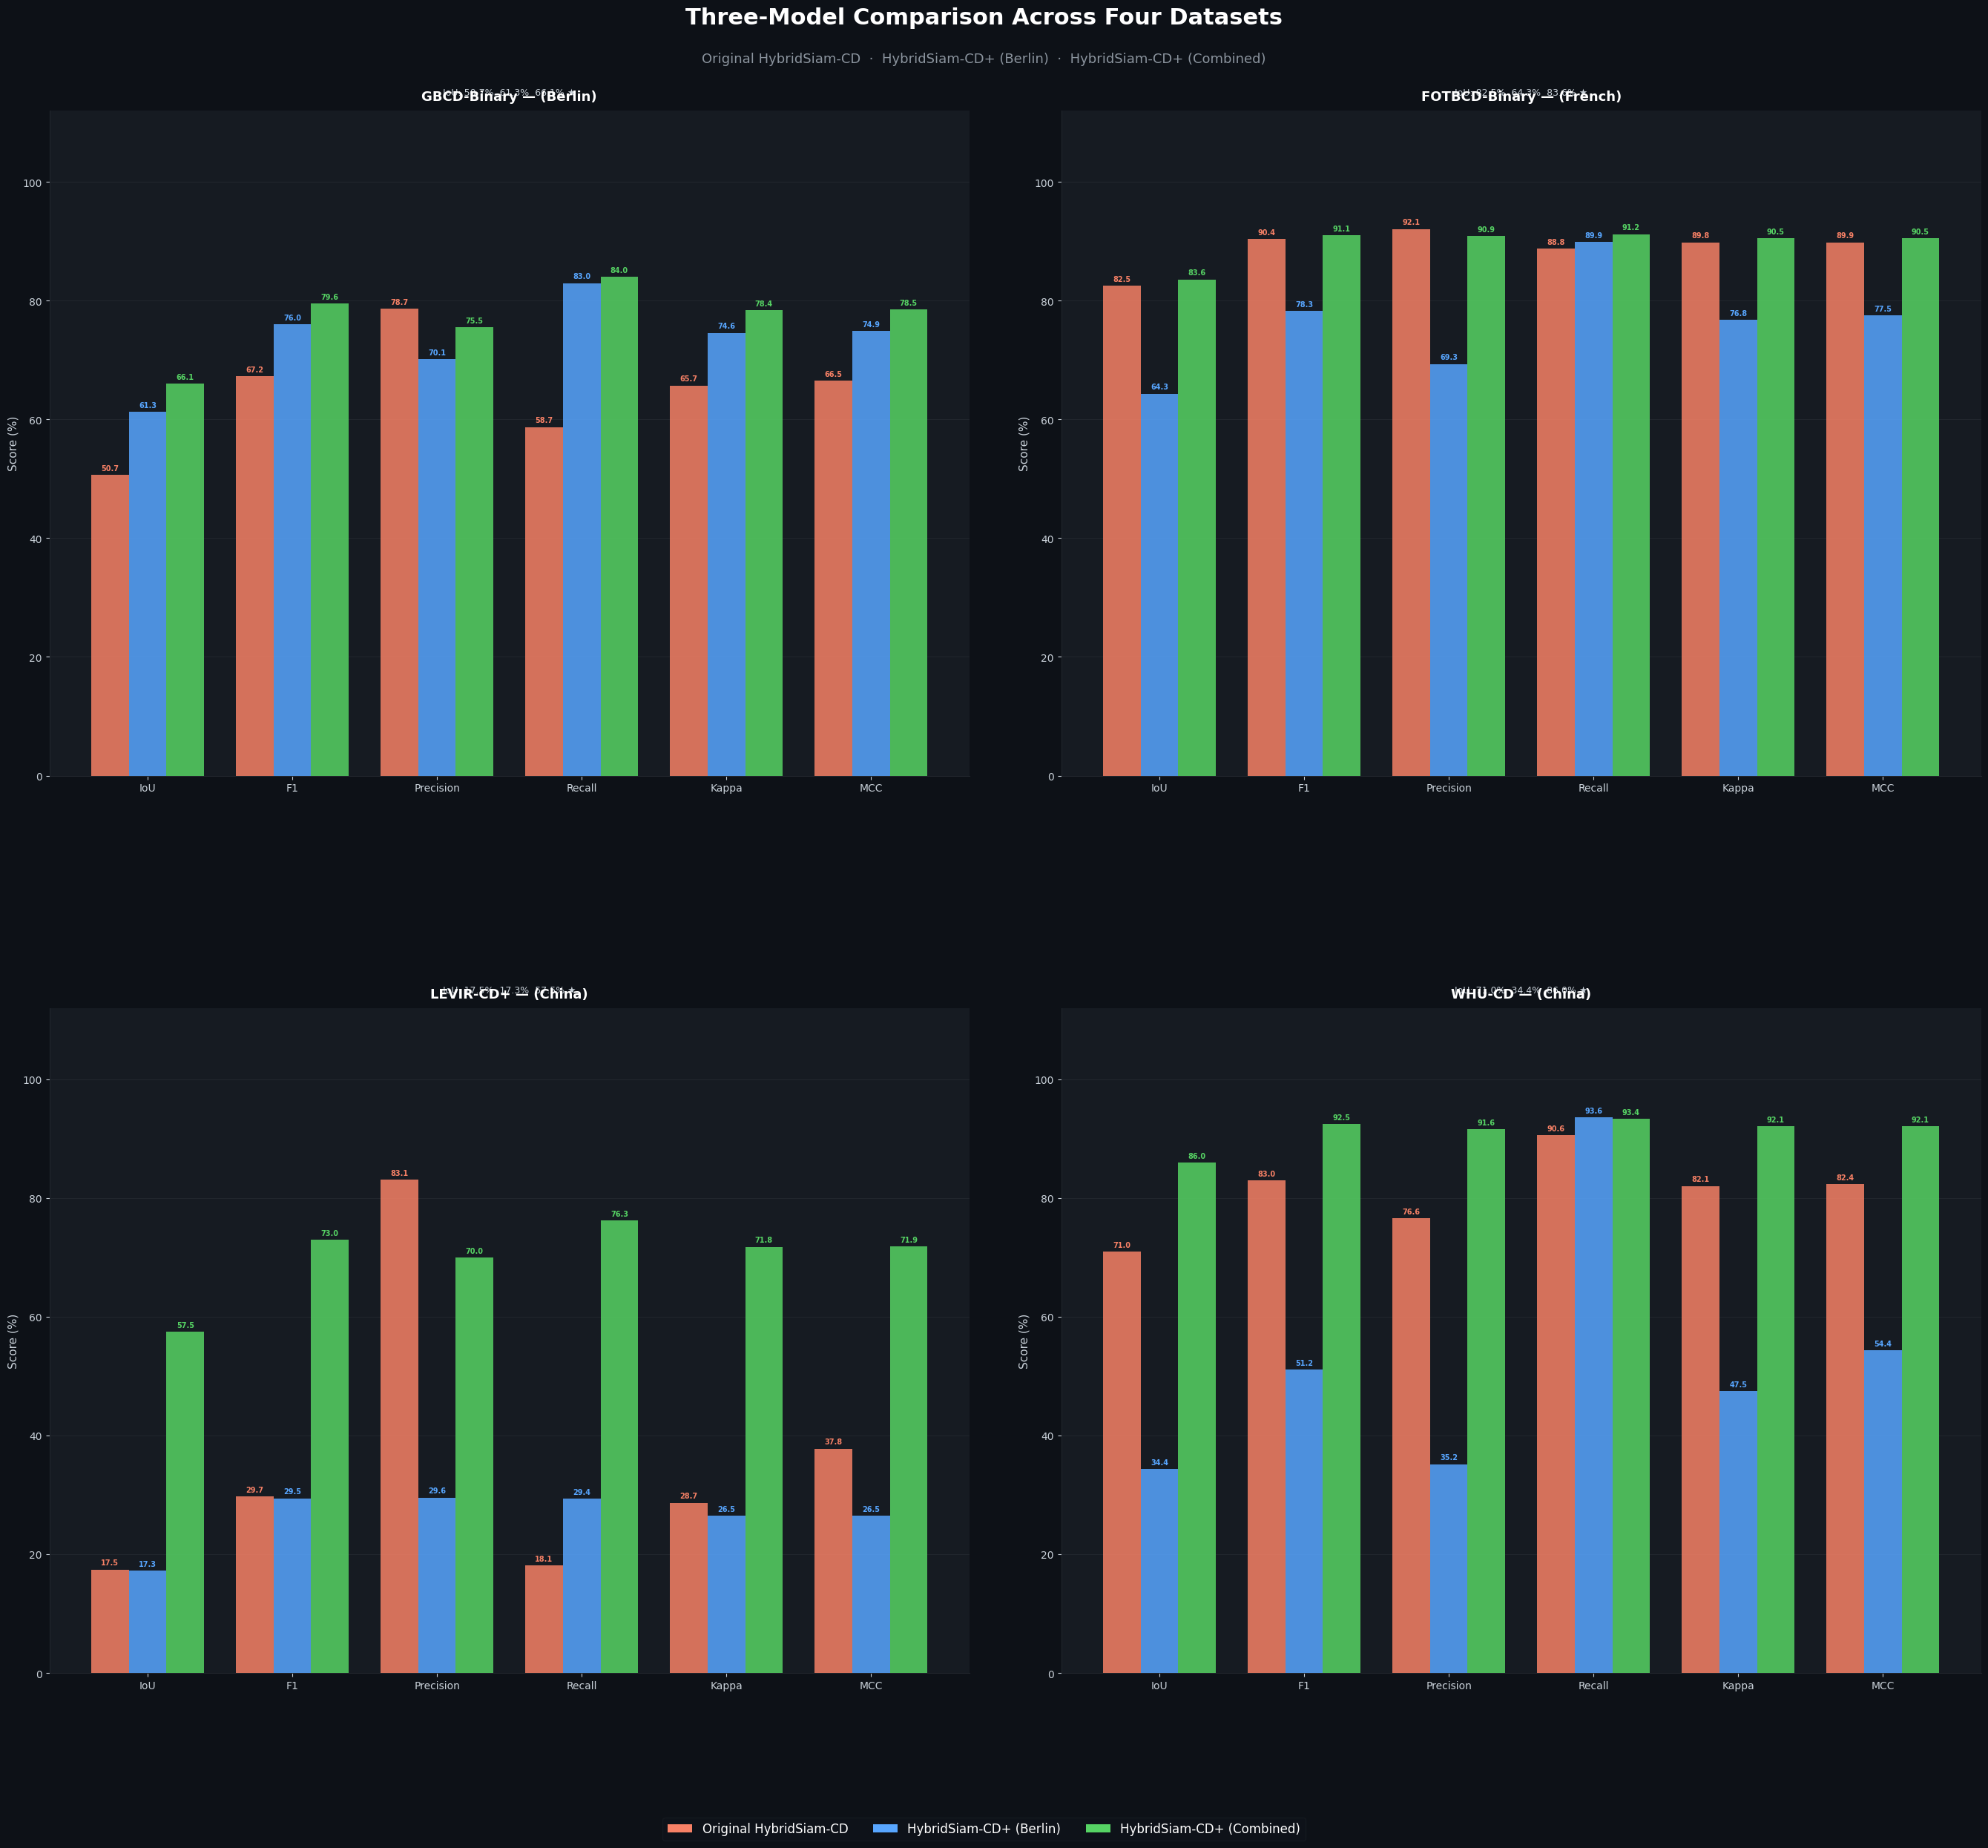

Chart saved → /content/evaluation/three_model_comparison.png


In [ ]:
# ── CELL 9: Visualisation ─────────────────────────────────────────────────────
BG     = '#0d1117'
PANEL  = '#161b22'
GRID_C = '#21262d'
TEXT_C = '#c9d1d9'

model_names   = list(MODELS.keys())
model_colors  = [MODELS[m]['color'] for m in model_names]
model_labels  = [m.replace('\n',' ') for m in model_names]
dataset_names = list(DATASETS.keys())

key_metrics   = ['iou','f1','precision','recall','kappa','mcc']
metric_labels = ['IoU','F1','Precision','Recall','Kappa','MCC']

n_ds  = len(dataset_names)
n_mod = len(model_names)

fig = plt.figure(figsize=(28, 26), facecolor=BG)

# Title
fig.text(0.5, 0.975,
         'Three-Model Comparison Across Four Datasets',
         ha='center', fontsize=22, fontweight='bold', color='white')
fig.text(0.5, 0.955,
         'Original HybridSiam-CD  ·  HybridSiam-CD+ (Berlin)  ·  HybridSiam-CD+ (Combined)',
         ha='center', fontsize=13, color='#8b949e')

outer = gridspec.GridSpec(2, 2, figure=fig,
                          hspace=0.35, wspace=0.10,
                          top=0.93, bottom=0.12,
                          left=0.05, right=0.98)

x     = np.arange(len(key_metrics))
width = 0.26
offsets = [-width, 0, width]

for ds_idx, ds_name in enumerate(dataset_names):
    row, col = divmod(ds_idx, 2)
    ax = fig.add_subplot(outer[row, col])
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT_C, labelsize=10)
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom','left']:
        ax.spines[spine].set_color(GRID_C)
    ax.yaxis.grid(True, color=GRID_C, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    for mi, (m_name, offset, color) in enumerate(
            zip(model_names, offsets, model_colors)):
        vals = [
            results[m_name].get(ds_name,{}).get(met,0)*100
            for met in key_metrics
        ]
        bars = ax.bar(x + offset, vals, width,
                      color=color, alpha=0.85,
                      zorder=3, edgecolor='none',
                      label=model_labels[mi])
        for bar in bars:
            h = bar.get_height()
            if h > 5:
                ax.text(bar.get_x()+bar.get_width()/2, h+0.5,
                        f'{h:.1f}', ha='center', va='bottom',
                        fontsize=7, color=color, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=10, color=TEXT_C)
    ax.set_ylabel('Score (%)', fontsize=11, color=TEXT_C)
    ax.set_ylim(0, 112)
    ax.set_title(ds_name.replace('\n',' — '),
                 fontsize=13, fontweight='bold',
                 color='white', pad=10)

    # IoU annotations for each model
    iou_vals = [
        results[m].get(ds_name,{}).get('iou',0)*100
        for m in model_names
    ]
    best_iou = max(iou_vals)
    annot = '  '.join(
        f'{v:.1f}%{" ★" if v==best_iou else ""}'
        for v in iou_vals
    )
    ax.text(0.5, 1.02, f'IoU: {annot}',
            transform=ax.transAxes,
            ha='center', va='bottom',
            fontsize=9, color=TEXT_C)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=c, label=l)
    for c, l in zip(model_colors, model_labels)
]
fig.legend(handles=legend_elements,
           loc='lower center', ncol=3,
           fontsize=12, framealpha=0.2,
           labelcolor='white', facecolor=PANEL,
           edgecolor='#30363d',
           bbox_to_anchor=(0.5, 0.03),
           handlelength=2)

chart_path = os.path.join(SAVE_DIR, 'three_model_comparison.png')
plt.savefig(chart_path, dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print(f'Chart saved → {chart_path}')

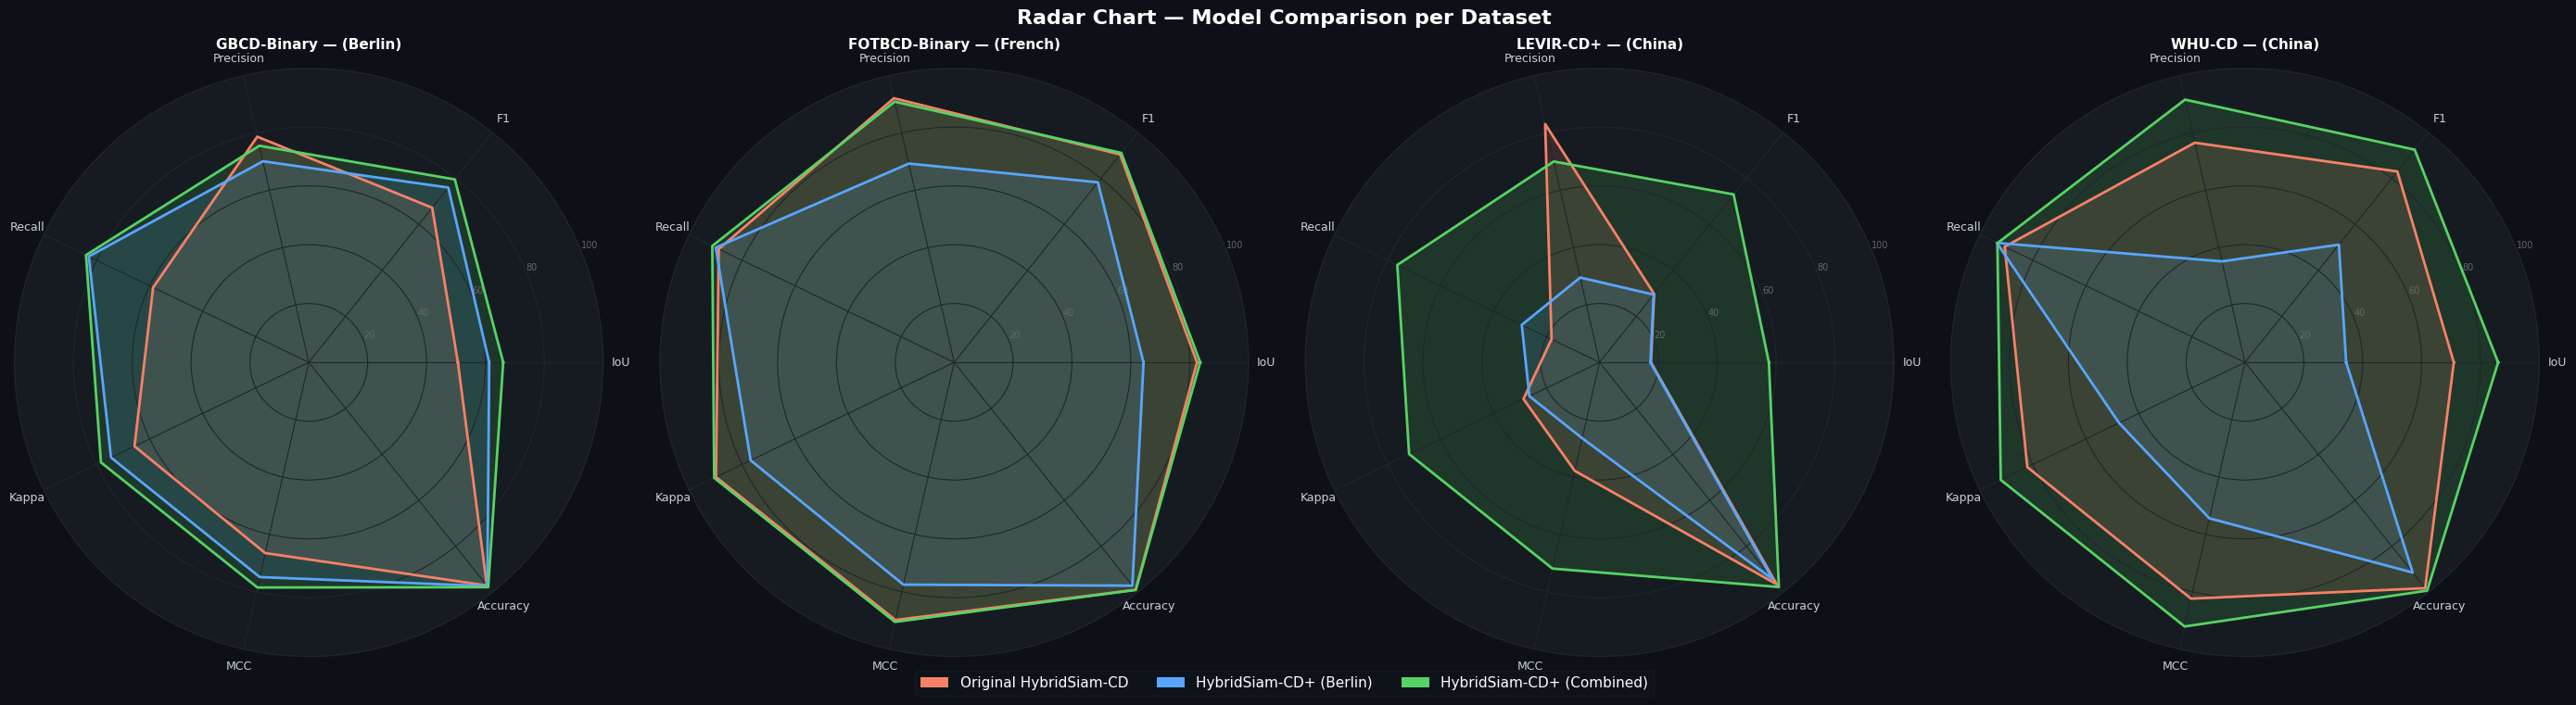

Radar chart saved → /content/evaluation/radar_chart.png


In [ ]:
# ── CELL 10: Radar chart ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

radar_metrics = ['IoU','F1','Precision','Recall','Kappa','MCC','Accuracy']
radar_keys    = ['iou','f1','precision','recall','kappa','mcc','accuracy']
N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 4, figsize=(28, 7),
                         subplot_kw=dict(polar=True),
                         facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('Radar Chart — Model Comparison per Dataset',
             fontsize=16, fontweight='bold',
             color='white', y=1.02)

for ax_idx, (ds_name, ax) in enumerate(
        zip(dataset_names, axes)):
    ax.set_facecolor(PANEL)
    ax.set_title(ds_name.replace('\n',' — '),
                 fontsize=11, fontweight='bold',
                 color='white', pad=15)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics,
                       fontsize=9, color=TEXT_C)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['20','40','60','80','100'],
                       fontsize=7, color='#666')
    ax.set_ylim(0, 1)
    ax.grid(color=GRID_C, linewidth=0.8)
    ax.spines['polar'].set_color(GRID_C)

    for m_name, color in zip(model_names, model_colors):
        vals = [
            results[m_name].get(ds_name,{}).get(k, 0)
            for k in radar_keys
        ]
        vals += vals[:1]
        ax.plot(angles, vals, color=color,
                linewidth=2, linestyle='solid')
        ax.fill(angles, vals, color=color, alpha=0.15)

legend_elements = [
    mpatches.Patch(facecolor=c, label=l)
    for c, l in zip(model_colors, model_labels)
]
fig.legend(handles=legend_elements,
           loc='lower center', ncol=3,
           fontsize=11, framealpha=0.2,
           labelcolor='white', facecolor=PANEL,
           edgecolor='#30363d',
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
radar_path = os.path.join(SAVE_DIR, 'radar_chart.png')
plt.savefig(radar_path, dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print(f'Radar chart saved → {radar_path}')

In [ ]:
# ── CELL 11: Save results + copy to Drive ─────────────────────────────────────
import shutil

txt_path = os.path.join(SAVE_DIR, 'three_model_results.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write('Three-Model x Four-Dataset Evaluation\n')
    f.write(f'Timestamp: {time.strftime("%Y-%m-%d %H:%M:%S")}\n\n')
    for ds_name in DATASETS:
        clean = ds_name.replace('\n',' ')
        f.write(f'\n{"="*80}\n  {clean}\n{"="*80}\n')
        f.write(f'  {"Metric":<14} {"Original":>12} '
                f'{"Berlin":>14} {"Combined":>14}\n')
        f.write(f'  {"-"*60}\n')
        for metric in metrics_list:
            v1=results[m1].get(ds_name,{}).get(metric,None)
            v2=results[m2].get(ds_name,{}).get(metric,None)
            v3=results[m3].get(ds_name,{}).get(metric,None)
            s1=f'{v1*100:>11.2f}%' if v1 else f'{"N/A":>12}'
            s2=f'{v2*100:>13.2f}%' if v2 else f'{"N/A":>14}'
            s3=f'{v3*100:>13.2f}%' if v3 else f'{"N/A":>14}'
            f.write(f'  {metric:<14}{s1}{s2}{s3}\n')

# Copy to Drive
drive_dir = '/content/drive/MyDrive/GBCD/evaluation_results'
os.makedirs(drive_dir, exist_ok=True)
for src in [chart_path, radar_path, txt_path]:
    shutil.copy(src, os.path.join(drive_dir, os.path.basename(src)))

print('All results saved to Drive!')
print(f'  three_model_comparison.png')
print(f'  radar_chart.png')
print(f'  three_model_results.txt')

All results saved to Drive!
  three_model_comparison.png
  radar_chart.png
  three_model_results.txt
